# VN Portfolio Screener

Pipeline: Fetch giá → Lọc thanh khoản → CAGR/Sharpe → Correlation clustering → 6 mã output


## Cell 1 — Cài thư viện


In [1]:
!pip install vnstock openpyxl pandas numpy scipy scikit-learn matplotlib seaborn -q



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Import


In [2]:
import time, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)


## Cell 3 — Universe cổ phiếu


In [3]:
SECTOR_STOCKS = {
    'cong nghiep & logistics': [
        'GMD','HAH','VSC','PVT','VOS','VTO','STG','SFI','GSP','MHC',
        'HVN','VJC','SCS','AST','SKG','VTP','TOT','ASG','TMS',
        'GEX','GEE','REE','VEA','CAV','TLG','GDT','CTR',
        'BCM','KBC','PHR','SZL','LHG','SZC','TIP','D2D','GVR','IDC',
    ],
    'Tai chinh ngan hang': [
        'VCB','BID','CTG','TCB','VPB','MBB','HDB','LPB','ACB',
        'STB','SHB','VIB','TPB','SSB','EIB','MSB','OCB','EVF',
        'KLB','VAB','TCX',
        'SSI','VCK','VPX','VIX','VCI','VND','FTS','DSE','BSI',
        'ORS','CTS','VDS','DSC','AGR',
    ],
    'Tieu dung': [
        'VNM','MSN','SBT','HAG','KDC','VHC','BAF','DBC','VCF',
        'ANV','PAN','MCM','FMC','IDI','CLC','NSC','OGC','ANT',
        'LSS','ABT','CMX','ACL','DAT','TSC','SSC','AFX','LAF',
        'HSL','AAM','MCH','VMD','LIX','SGT','FIT','DLG','SAB',
        'BHN','NAF','SMB',
    ],
    'Xay dung ha tang': [
        'CTD','HBC','VCG','FCN','LCG','HAS','HU1','HU3','HUB',
        'C47','C32','LM8','MCG','CIG','DC4','ACC','HID','CEE',
        'NHA','MDG','CDC','CII','HHV','DPG','PC1','CTI','HTI',
        'BCE','FCM','HVH','SC5','HPG','HSG','NKG','TVN','POM',
        'SMC','TIS','VGS','HMC','VIS','HT1','HVX','DXV','CVT',
        'DHA','VGC','BMP','NNC','LBM','PTB','NAV','NTP','EVG',
    ],
    'Cong nghe': ['MWG','FRT','PET','FPT','VGT','HIG','PMG'],
}

ALL_SYMBOLS, SYMBOL_TO_SECTOR = [], {}
seen = set()
for sector, syms in SECTOR_STOCKS.items():
    for s in syms:
        if s not in seen:
            seen.add(s)
            ALL_SYMBOLS.append(s)
            SYMBOL_TO_SECTOR[s] = sector

print(f'{len(ALL_SYMBOLS)} ma, {len(SECTOR_STOCKS)} nganh')
for sec, syms in SECTOR_STOCKS.items():
    print(f'  {sec}: {len(syms)} ma')


172 ma, 5 nganh
  cong nghiep & logistics: 37 ma
  Tai chinh ngan hang: 35 ma
  Tieu dung: 39 ma
  Xay dung ha tang: 54 ma
  Cong nghe: 7 ma


## Cell 4 — Cấu hình


In [16]:
FETCH_START   = '2023-06-01'
FETCH_END     = '2025-12-31'
PRICE_SCALE   = 1e6          # vnstock tra gia nghin dong
DELAY_SEC     = 3
SOURCES       = ['VCI', 'TCBS']
BATCH_SIZE    = 18

SECTOR_MIN_LIQ = {
    'Tai chinh ngan hang': 10.0,
    'Tieu dung':            3.0,
    'cong nghiep & logistics': 3.0,
    'Cong nghe':            2.0,
    'Xay dung ha tang':     2.0,
    '_default':             1.5,
}

MIN_CAGR       = 0.25
MIN_WEEKS      = 10
N_CLUSTERS     = 6
MAX_PER_CLUSTER= 1
RISK_FREE      = 0.0273
WEEKS_PER_YEAR = 52

print('Config OK')


Config OK


## Cell 5 — Fetch giá


In [5]:
from vnstock import Quote

class RateLimiter:
    def __init__(self, calls=18, window=62):
        self.calls, self.window = calls, window
        self.ts = collections.deque()

    def wait(self):
        now = time.time()
        while self.ts and now - self.ts[0] > self.window:
            self.ts.popleft()
        if len(self.ts) >= self.calls:
            sleep = self.window - (now - self.ts[0]) + 1
            if sleep > 0:
                print(f'  rate limit: nghi {int(sleep)}s')
                time.sleep(sleep)
        self.ts.append(time.time())


def fetch_price(sym, start, end, rl):
    for src in SOURCES:
        try:
            rl.wait()
            time.sleep(DELAY_SEC)
            df = Quote(source=src, symbol=sym,
                       random_agent=False, show_log=False
                       ).history(start=start, end=end, interval='1D')
            if df is None or df.empty:
                continue

            df.columns = [c.lower().strip() for c in df.columns]
            date_col  = next((c for c in ['time','date','tradingdate'] if c in df.columns), None)
            close_col = next((c for c in ['close','closeprice','adjclose'] if c in df.columns), None)
            vol_col   = next((c for c in ['volume','tradingvolume','vol'] if c in df.columns), None)

            if date_col:
                df[date_col] = pd.to_datetime(df[date_col])
                df = df.set_index(date_col).sort_index()
            elif isinstance(df.index, pd.DatetimeIndex):
                df = df.sort_index()
            else:
                continue

            if close_col is None:
                continue

            out = df[[close_col]].rename(columns={close_col: 'close'})
            out['close']  = pd.to_numeric(out['close'], errors='coerce')
            out['volume'] = pd.to_numeric(df[vol_col], errors='coerce') if vol_col else np.nan
            out = out.dropna(subset=['close'])
            out = out[out['close'] > 0]

            if len(out) >= MIN_WEEKS:
                return out
        except Exception as e:
            err = str(e).lower()
            if '403' in err or 'forbidden' in err: time.sleep(15)
            if '429' in err or 'rate' in err:      time.sleep(30)
    return None


price_data, errors = {}, {}
rl = RateLimiter(BATCH_SIZE, 62)

for i, sym in enumerate(ALL_SYMBOLS, 1):
    if i > 1 and (i-1) % BATCH_SIZE == 0:
        print('  batch pause 62s...')
        time.sleep(62)

    print(f'[{i:03d}/{len(ALL_SYMBOLS)}] {sym:<6} ...', end=' ', flush=True)
    df = fetch_price(sym, FETCH_START, FETCH_END, rl)
    if df is None:
        errors[sym] = 'skip'
        print('SKIP')
    else:
        price_data[sym] = df
        liq = float((df['close'] * df['volume'].fillna(0)).mean() / PRICE_SCALE)
        print(f'{len(df)} ngay  liq={liq:.1f}ty')

print(f'\nOK={len(price_data)}  SKIP={len(errors)}')
if errors:
    print(f'Skip: {sorted(errors)}')


[001/172] GMD    ... 677 ngay  liq=94.0ty
[002/172] HAH    ... 677 ngay  liq=99.9ty
[003/172] VSC    ... 677 ngay  liq=103.7ty
[004/172] PVT    ... 677 ngay  liq=61.0ty
[005/172] VOS    ... 677 ngay  liq=31.8ty
[006/172] VTO    ... 677 ngay  liq=6.3ty
[007/172] STG    ... 677 ngay  liq=0.3ty
[008/172] SFI    ... 677 ngay  liq=0.2ty
[009/172] GSP    ... 677 ngay  liq=2.3ty
[010/172] MHC    ... 677 ngay  liq=2.8ty
[011/172] HVN    ... 677 ngay  liq=42.7ty
[012/172] VJC    ... 677 ngay  liq=131.3ty
[013/172] SCS    ... 677 ngay  liq=13.4ty
[014/172] AST    ... 677 ngay  liq=1.0ty
[015/172] SKG    ... 677 ngay  liq=6.1ty
[016/172] VTP    ... 677 ngay  liq=78.2ty
[017/172] TOT    ... 677 ngay  liq=0.1ty
[018/172] ASG    ... 677 ngay  liq=0.1ty
  batch pause 62s...
[019/172] TMS    ... 677 ngay  liq=0.3ty
[020/172] GEX    ... 677 ngay  liq=360.6ty
[021/172] GEE    ... 677 ngay  liq=36.0ty
[022/172] REE    ... 677 ngay  liq=41.4ty
[023/172] VEA    ... 677 ngay  liq=23.1ty
[024/172] CAV    ...

## Cell 6 — Lọc thanh khoản


In [6]:
liq_passed, liq_values = [], {}

for sym, df in price_data.items():
    # dung 26 tuan (~6 thang) gan nhat — phan anh kha nang giao dich hien tai
    recent = df.last('182D')
    liq = float((recent['close'] * recent['volume'].fillna(0)).mean() / PRICE_SCALE)
    sec = SYMBOL_TO_SECTOR.get(sym, '_default')
    thr = SECTOR_MIN_LIQ.get(sec, SECTOR_MIN_LIQ['_default'])
    liq_values[sym] = liq
    if liq >= thr:
        liq_passed.append(sym)
    else:
        print(f'  loai {sym:<6}  {liq:.2f}ty < {thr:.1f}ty')

print(f'\npass={len(liq_passed)}  loai={len(price_data)-len(liq_passed)}')
for sec, syms in SECTOR_STOCKS.items():
    n_in = [s for s in syms if s in price_data]
    n_ok = [s for s in n_in if s in liq_passed]
    print(f'  {sec:<35} {len(n_ok)}/{len(n_in)}')


  loai STG     0.02ty < 3.0ty
  loai SFI     0.08ty < 3.0ty
  loai GSP     0.96ty < 3.0ty
  loai AST     1.02ty < 3.0ty
  loai SKG     2.31ty < 3.0ty
  loai TOT     0.14ty < 3.0ty
  loai ASG     0.05ty < 3.0ty
  loai TMS     0.11ty < 3.0ty
  loai CAV     0.69ty < 3.0ty
  loai GDT     0.77ty < 3.0ty
  loai SZL     0.46ty < 3.0ty
  loai TIP     2.50ty < 3.0ty
  loai KLB     9.36ty < 10.0ty
  loai DSC     3.08ty < 10.0ty
  loai VCF     0.41ty < 3.0ty
  loai MCM     1.01ty < 3.0ty
  loai CLC     0.18ty < 3.0ty
  loai NSC     0.21ty < 3.0ty
  loai ANT     1.71ty < 3.0ty
  loai ABT     0.81ty < 3.0ty
  loai CMX     2.04ty < 3.0ty
  loai ACL     0.45ty < 3.0ty
  loai DAT     0.11ty < 3.0ty
  loai TSC     2.37ty < 3.0ty
  loai SSC     0.02ty < 3.0ty
  loai AFX     1.84ty < 3.0ty
  loai LAF     0.12ty < 3.0ty
  loai AAM     0.05ty < 3.0ty
  loai VMD     0.33ty < 3.0ty
  loai LIX     1.63ty < 3.0ty
  loai SGT     0.93ty < 3.0ty
  loai BHN     0.24ty < 3.0ty
  loai SMB     0.85ty < 3.0ty
  loai H

## Cell 7 — CAGR + Sharpe


In [17]:
weekly_close, stats = {}, {}

for sym in liq_passed:
    w = price_data[sym]['close'].resample('W-FRI').last().dropna()
    if len(w) < MIN_WEEKS:
        continue

    years = (len(w) - 1) / WEEKS_PER_YEAR
    if years <= 0:
        continue

    # dung trung binh 4 tuan dau/cuoi — giam nhaycam voi outlier diem dau/cuoi
    n_avg = min(4, len(w) // 4)
    p0    = float(w.iloc[:n_avg].mean())
    p1    = float(w.iloc[-n_avg:].mean())
    cagr  = (p1/p0)**(1/years) - 1 if p0 > 0 else 0.0
    vol   = float(w.pct_change().dropna().std() * np.sqrt(WEEKS_PER_YEAR))
    sharpe = (cagr - RISK_FREE) / vol if vol > 0 else 0.0

    weekly_close[sym] = w
    stats[sym] = {
        'cagr': cagr, 'vol': vol, 'sharpe': sharpe,
        'n': len(w), 'liq': liq_values.get(sym, 0),
        'sector': SYMBOL_TO_SECTOR.get(sym, ''),
    }

cagr_passed = [s for s in stats if stats[s]['cagr'] >= MIN_CAGR]
cagr_failed = [s for s in stats if stats[s]['cagr'] <  MIN_CAGR]

print(f'CAGR >= {MIN_CAGR:.0%}:  pass={len(cagr_passed)}  loai={len(cagr_failed)}')
if cagr_failed:
    for s in sorted(cagr_failed, key=lambda x: stats[x]['cagr']):
        print(f'  {s:<6}  CAGR={stats[s]["cagr"]:+.1%}')

df_stats = (pd.DataFrame(stats).T.loc[cagr_passed]
            .astype({'cagr':float,'vol':float,'sharpe':float,'n':int,'liq':float})
            .sort_values('sharpe', ascending=False))
display(df_stats[['sector','cagr','vol','sharpe','liq','n']])
print(f'\n{len(cagr_passed)} ma vao clustering')


CAGR >= 20%:  pass=51  loai=61
  POM     CAGR=-26.4%
  OGC     CAGR=-25.0%
  SAB     CAGR=-12.8%
  IDI     CAGR=-11.7%
  SSB     CAGR=-9.8%
  HBC     CAGR=-8.0%
  BCM     CAGR=-7.3%
  KDC     CAGR=-6.5%
  FMC     CAGR=-1.9%
  FIT     CAGR=+0.2%
  SCS     CAGR=+0.2%
  LCG     CAGR=+0.5%
  MSN     CAGR=+0.6%
  LSS     CAGR=+1.0%
  DSE     CAGR=+1.3%
  VNM     CAGR=+2.0%
  HSG     CAGR=+3.7%
  VGT     CAGR=+3.7%
  VCB     CAGR=+4.6%
  HT1     CAGR=+5.0%
  DLG     CAGR=+5.4%
  PC1     CAGR=+5.5%
  VHC     CAGR=+6.5%
  BID     CAGR=+6.8%
  TCX     CAGR=+7.3%
  VOS     CAGR=+8.4%
  SMC     CAGR=+8.9%
  TLG     CAGR=+10.0%
  IDC     CAGR=+10.1%
  KBC     CAGR=+10.2%
  VEA     CAGR=+10.4%
  NKG     CAGR=+10.5%
  HHV     CAGR=+10.7%
  PTB     CAGR=+10.8%
  LHG     CAGR=+10.8%
  VGC     CAGR=+11.0%
  PVT     CAGR=+11.0%
  ORS     CAGR=+11.5%
  FCN     CAGR=+12.2%
  SZC     CAGR=+12.6%
  TPB     CAGR=+13.1%
  CTR     CAGR=+13.2%
  PET     CAGR=+13.3%
  EIB     CAGR=+14.2%
  NHA     CAGR=+14.5%
  

,sector,cagr,vol,sharpe,liq,n
GEE,cong nghiep & logistics,1.4472,0.5482,2.5899,121.2402,142
MCH,Tieu dung,0.9427,0.3605,2.5388,59.0705,142
LPB,Tai chinh ngan hang,0.8175,0.3308,2.3889,137.2474,141
NNC,Xay dung ha tang,0.6977,0.2840,2.3605,3.1042,141
NAF,Tieu dung,0.6098,0.2784,2.0921,19.2718,141
HDB,Tai chinh ngan hang,0.4564,0.2725,1.5746,468.3202,141
HAH,cong nghiep & logistics,0.5521,0.3442,1.5249,165.0063,141
FRT,Cong nghe,0.5493,0.3429,1.5221,82.8231,141
BMP,Xay dung ha tang,0.5126,0.3224,1.5054,21.8194,141
TCB,Tai chinh ngan hang,0.3945,0.2650,1.3855,696.0997,141



51 ma vao clustering


## Cell 8 — Correlation + Clustering


Vao clustering: 51 ma  (144 tuan)

6 clusters:
  C1: 19 ma  best=HAH(1.52)  [HAH, HVN, VTP, D2D, GVR, SBT, DBC, ANV...]
  C2: 7 ma  best=HDB(1.57)  [VJC, CTG, TCB, MBB, HDB, ACB, STB]
  C3: 14 ma  best=VIX(1.29)  [MHC, GEX, SHB, EVF, VAB, SSI, VIX, FTS...]
  C4: 3 ma  best=LPB(2.39)  [LPB, NAF, CDC]
  C5: 3 ma  best=GEE(2.59)  [GEE, HTI, NNC]
  C6: 5 ma  best=MCH(2.54)  [HAG, BAF, MCH, HID, HVH]


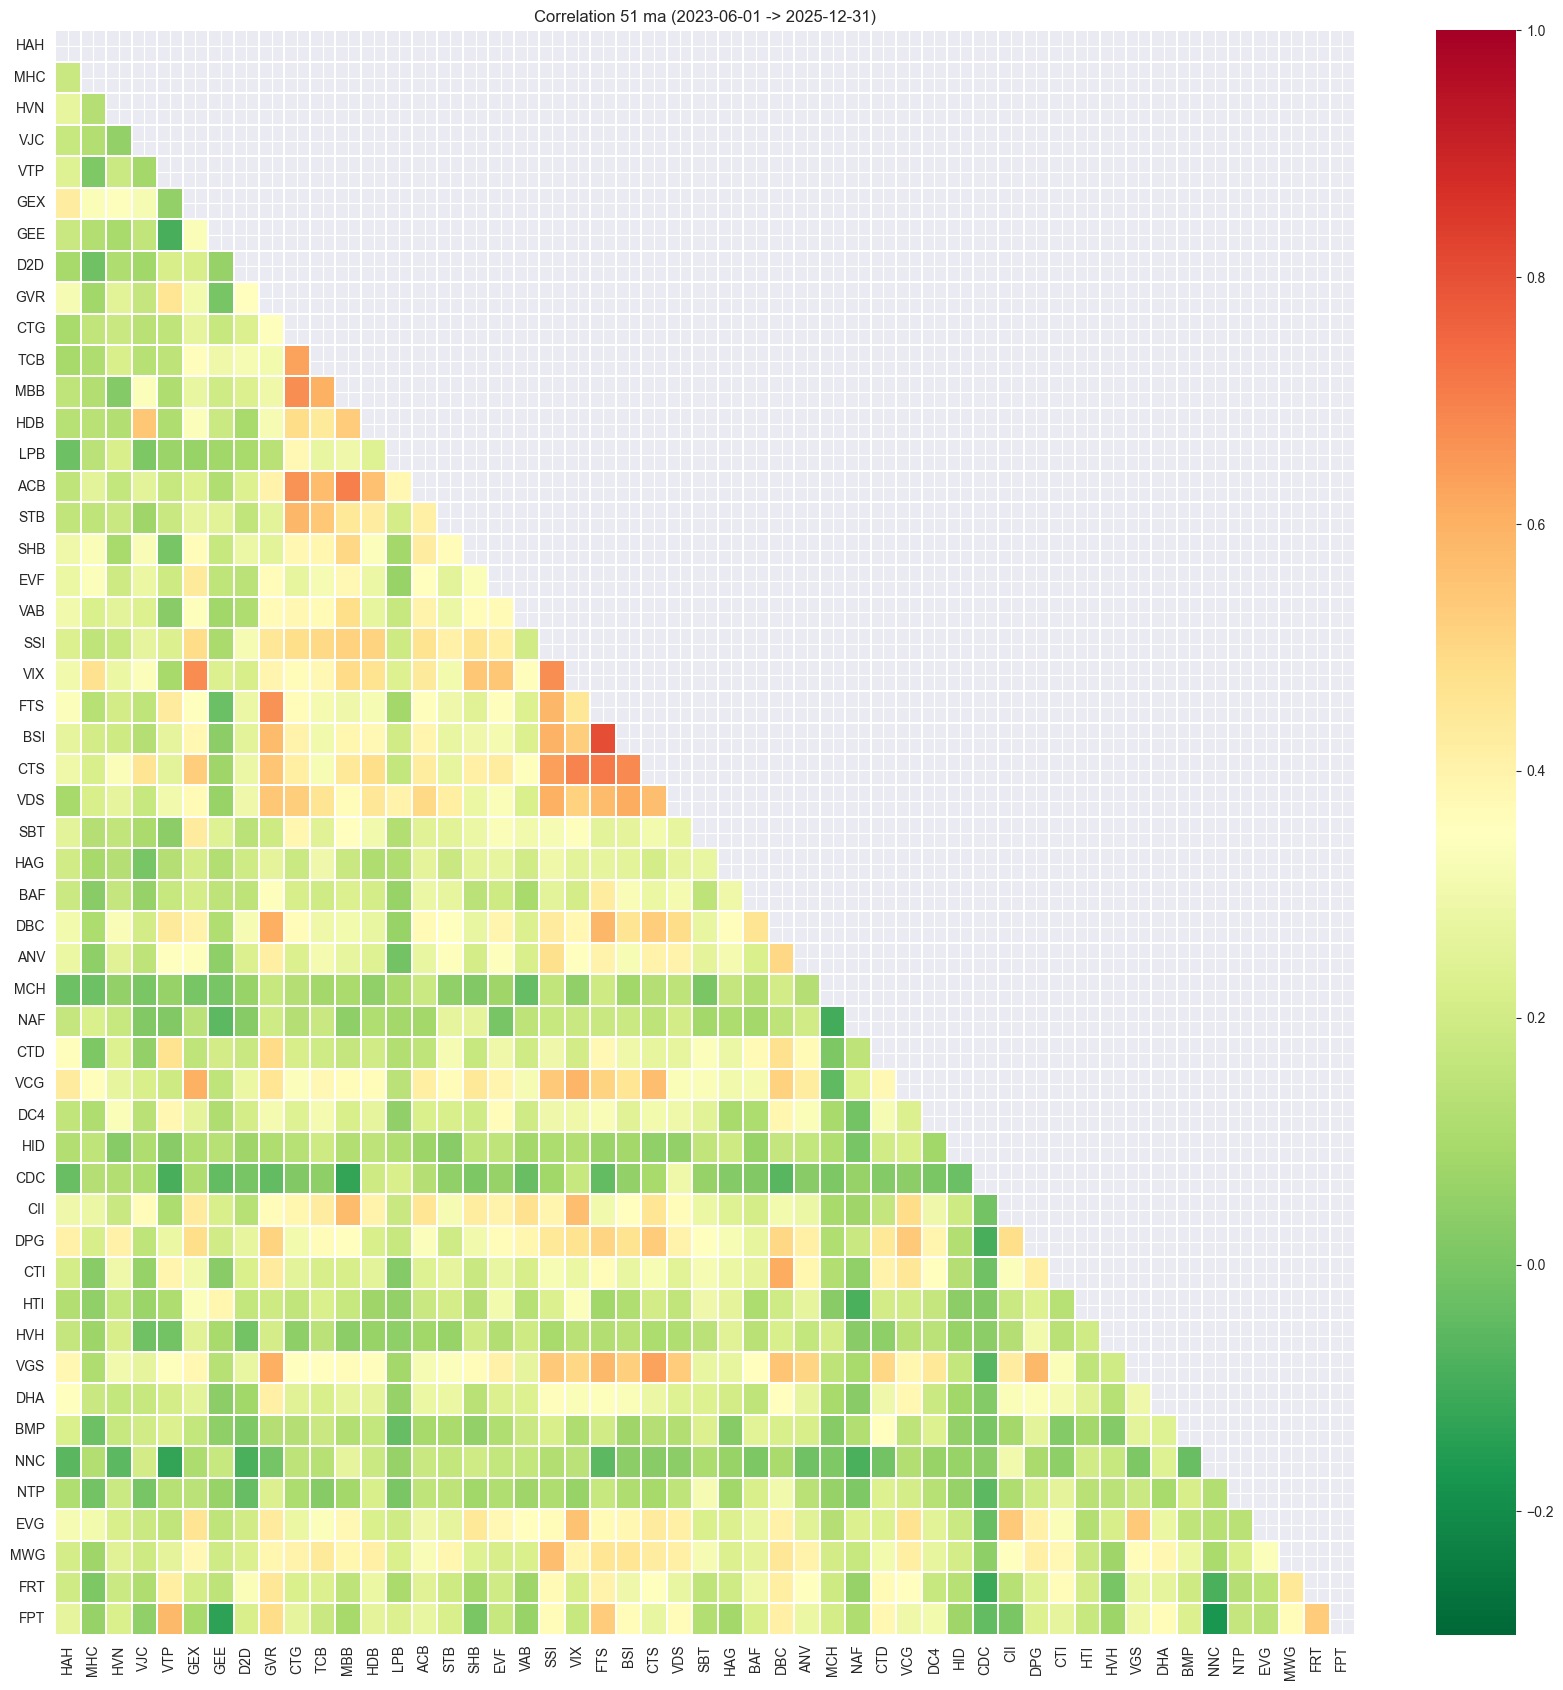

In [18]:
df_weekly  = pd.DataFrame({s: weekly_close[s] for s in cagr_passed}).sort_index()
df_returns = df_weekly.pct_change().dropna(how='all')
n_weeks    = len(df_returns)

min_valid  = max(8, int(n_weeks * 0.5))
valid_syms = [c for c in df_returns.columns if df_returns[c].notna().sum() >= min_valid]
dropped    = sorted(set(cagr_passed) - set(valid_syms))
if dropped:
    print(f'Bo {len(dropped)} ma thieu data (< {min_valid} tuan): {dropped}')

df_ret      = df_returns[valid_syms].dropna(how='all')
corr_matrix = df_ret.corr(method='pearson', min_periods=max(8, min_valid//2))

good_syms = [s for s in corr_matrix.columns if corr_matrix[s].notna().mean() >= 0.3]
dropped2  = sorted(set(valid_syms) - set(good_syms))
if dropped2:
    print(f'Bo {len(dropped2)} ma nan corr: {dropped2}')

print(f'Vao clustering: {len(good_syms)} ma  ({n_weeks} tuan)')

corr_matrix = corr_matrix.loc[good_syms, good_syms]

# impute NaN bang median cua tam giac tren (khong gom diagonal)
n_nan = corr_matrix.isna().sum().sum()
if n_nan > 0:
    upper_vals = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
    med = float(np.nanmedian(upper_vals))
    corr_matrix = corr_matrix.fillna(med)
    np.fill_diagonal(corr_matrix.values, 1.0)
    print(f'Impute {n_nan} NaN bang median off-diagonal = {med:.3f}')

# dam bao doi xung
arr = corr_matrix.values.astype(float)
arr = (arr + arr.T) / 2
np.fill_diagonal(arr, 1.0)
corr_matrix = pd.DataFrame(arr, index=good_syms, columns=good_syms)

N       = len(good_syms)
n_clust = min(N_CLUSTERS, N)
dist    = np.clip(1 - corr_matrix.values, 0, 2)
np.fill_diagonal(dist, 0)
Z       = linkage(squareform(dist, checks=False), method='ward')
labels  = fcluster(Z, t=n_clust, criterion='maxclust')

cluster_dict = collections.defaultdict(list)
for sym, lbl in zip(good_syms, labels):
    cluster_dict[int(lbl)].append(sym)

print(f'\n{n_clust} clusters:')
for cid in sorted(cluster_dict):
    syms_in = cluster_dict[cid]
    best    = max(syms_in, key=lambda s: stats[s]['sharpe'])
    print(f'  C{cid}: {len(syms_in)} ma  best={best}({stats[best]["sharpe"]:.2f})'
          f'  [{", ".join(syms_in[:8])}{"..." if len(syms_in)>8 else ""}]')

N_show = len(good_syms)
fig, ax = plt.subplots(figsize=(max(10, N_show//3), max(8, N_show//3)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            annot=(N_show <= 30), fmt='.2f', linewidths=0.3, ax=ax)
ax.set_title(f'Correlation {N_show} ma ({FETCH_START} -> {FETCH_END})')
plt.tight_layout()
plt.show()


## Cell 9 — Chọn đại diện mỗi cluster


In [19]:
selected_syms = []

for cid in sorted(cluster_dict):
    ranked = sorted(cluster_dict[cid], key=lambda s: stats[s]['sharpe'], reverse=True)
    picked = ranked[:MAX_PER_CLUSTER]
    others = ranked[MAX_PER_CLUSTER:]
    selected_syms.extend(picked)

    def fmt(s): return f"{s}({stats[s]['sharpe']:.2f})"
    rej = '  |  bo: ' + ', '.join(fmt(s) for s in others) if others else ''
    print(f'C{cid}: {", ".join(fmt(s) for s in picked)}{rej}')

print(f'\n{len(selected_syms)} ma duoc chon: {selected_syms}')


C1: HAH(1.52)  |  bo: FRT(1.52), BMP(1.51), VTP(1.32), DHA(1.24), D2D(1.14), NTP(1.01), MWG(1.00), DBC(0.99), FPT(0.96), HVN(0.93), SBT(0.84), DPG(0.78), VGS(0.76), CTI(0.69), CTD(0.60), DC4(0.55), GVR(0.52), ANV(0.50)
C2: HDB(1.57)  |  bo: TCB(1.39), MBB(1.36), CTG(1.08), STB(0.96), ACB(0.89), VJC(0.76)
C3: VIX(1.29)  |  bo: GEX(1.24), SHB(1.23), CTS(1.00), MHC(0.98), VAB(0.95), SSI(0.85), FTS(0.69), VDS(0.66), EVG(0.65), VCG(0.60), CII(0.58), BSI(0.50), EVF(0.47)
C4: LPB(2.39)  |  bo: NAF(2.09), CDC(0.77)
C5: GEE(2.59)  |  bo: NNC(2.36), HTI(1.17)
C6: MCH(2.54)  |  bo: BAF(1.36), HVH(0.97), HAG(0.91), HID(0.73)

6 ma duoc chon: ['HAH', 'HDB', 'VIX', 'LPB', 'GEE', 'MCH']


## Cell 10 — Kiểm tra chất lượng


corr TB toan bo  : 0.280
corr TB bo chon  : 0.132  (nen thap hon)
corr max bo chon : 0.347


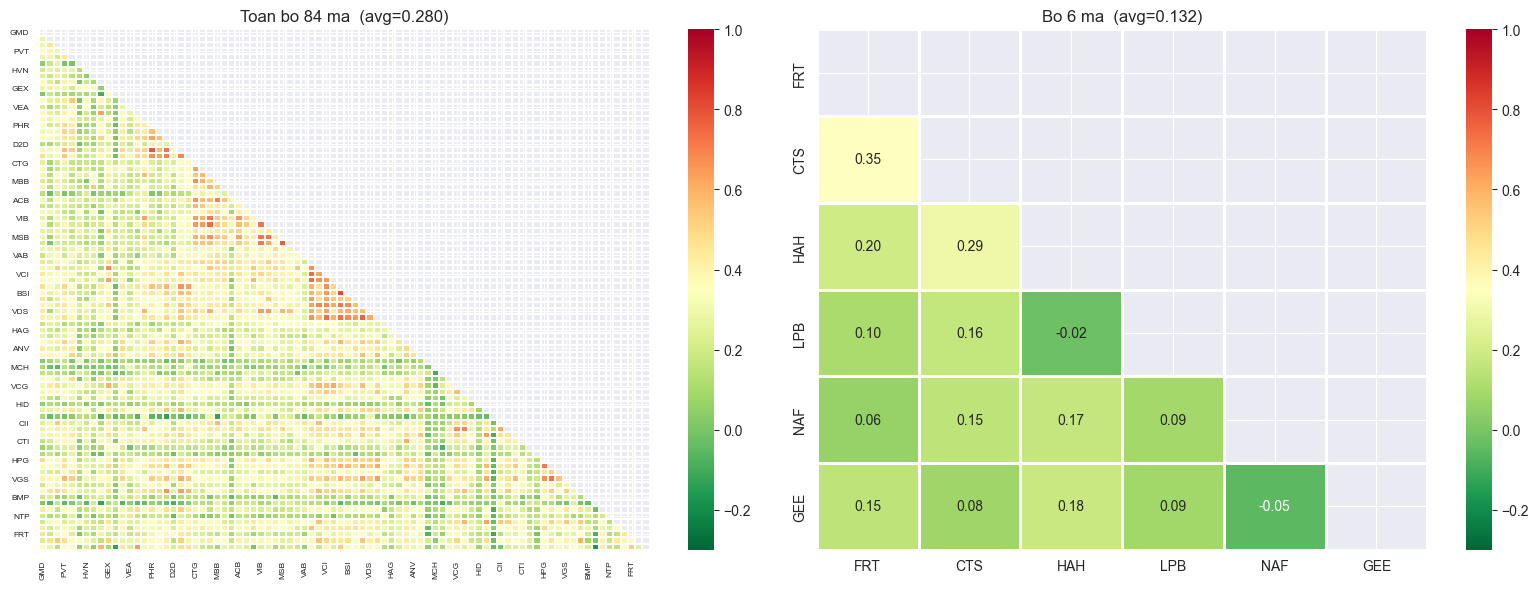

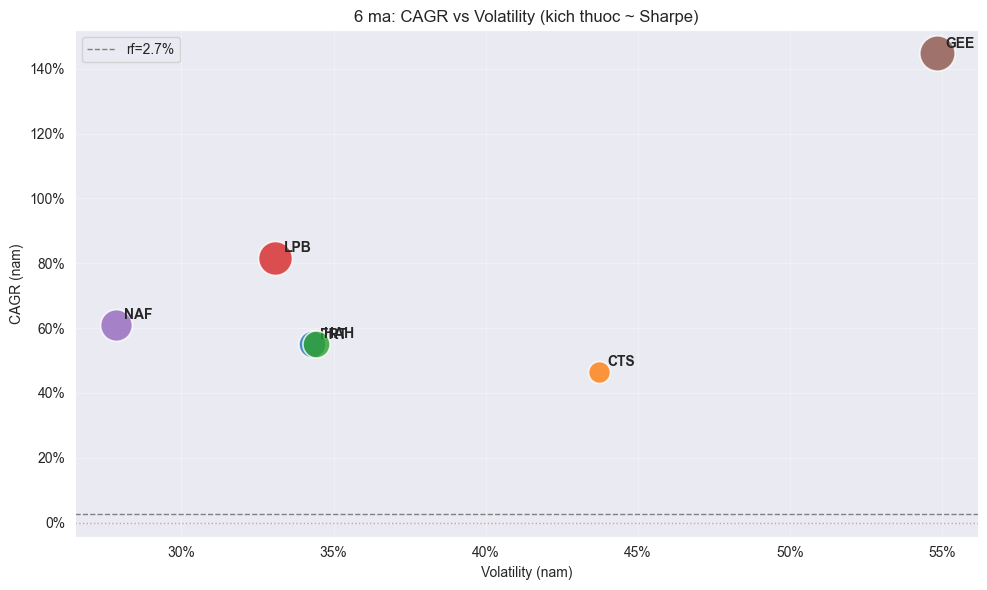

In [10]:
corr_sel  = corr_matrix.loc[selected_syms, selected_syms]
upper_all = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)).stack()
upper_sel = corr_sel.where(np.triu(np.ones_like(corr_sel, dtype=bool), k=1)).stack()

print(f'corr TB toan bo  : {upper_all.mean():.3f}')
print(f'corr TB bo chon  : {upper_sel.mean():.3f}  (nen thap hon)')
print(f'corr max bo chon : {upper_sel.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask_all = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask_all, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            ax=axes[0], annot=False, linewidths=0.2)
axes[0].set_title(f'Toan bo {N} ma  (avg={upper_all.mean():.3f})')
axes[0].tick_params(labelsize=6)

mask_sel = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(corr_sel, mask=mask_sel, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            ax=axes[1], annot=True, fmt='.2f', linewidths=0.8)
axes[1].set_title(f'Bo {len(selected_syms)} ma  (avg={upper_sel.mean():.3f})')

plt.tight_layout()
plt.show()

# scatter CAGR vs Vol
fig, ax = plt.subplots(figsize=(10, 6))
for sym in selected_syms:
    st = stats[sym]
    ax.scatter(st['vol'], st['cagr'], s=max(80, st['sharpe']*250),
               alpha=0.8, edgecolors='white', linewidths=1.2, zorder=3)
    ax.annotate(sym, (st['vol'], st['cagr']),
                textcoords='offset points', xytext=(6, 4), fontsize=10, fontweight='bold')

ax.axhline(RISK_FREE, color='gray', linestyle='--', linewidth=1, label=f'rf={RISK_FREE:.1%}')
ax.axhline(0, color='red', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Volatility (nam)')
ax.set_ylabel('CAGR (nam)')
ax.set_title('6 ma: CAGR vs Volatility (kich thuoc ~ Sharpe)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 11 — Output cuối


In [11]:
df_out = (pd.DataFrame(stats).T.loc[selected_syms]
          .astype({'cagr':float,'vol':float,'sharpe':float,'liq':float,'n':int})
          .sort_values('sharpe', ascending=False))
df_out['cluster'] = [next(c for c, ss in cluster_dict.items() if s in ss) for s in df_out.index]

disp = df_out[['cluster','sector','cagr','vol','sharpe','liq']].copy()
disp.columns = ['Cluster','Nganh','CAGR','Vol','Sharpe','Liq(ty)']
disp['CAGR'] = disp['CAGR'].map('{:+.1%}'.format)
disp['Vol']  = disp['Vol'].map('{:.1%}'.format)
display(disp)

print('\nFINAL_SYMBOLS = [')
for s in selected_syms:
    st = stats[s]
    print(f"    '{s}',   # {st['sector']}  CAGR={st['cagr']:+.1%}  Sharpe={st['sharpe']:.3f}")
print(']')


,Cluster,Nganh,CAGR,Vol,Sharpe,Liq(ty)
GEE,6,cong nghiep & logistics,+144.7%,54.8%,2.5899,121.2402
LPB,4,Tai chinh ngan hang,+81.8%,33.1%,2.3889,137.2474
NAF,5,Tieu dung,+61.0%,27.8%,2.0921,19.2718
HAH,3,cong nghiep & logistics,+55.2%,34.4%,1.5249,165.0063
FRT,1,Cong nghe,+54.9%,34.3%,1.5221,82.8231
CTS,2,Tai chinh ngan hang,+46.4%,43.7%,0.9995,97.5660



FINAL_SYMBOLS = [
    'FRT',   # Cong nghe  CAGR=+54.9%  Sharpe=1.522
    'CTS',   # Tai chinh ngan hang  CAGR=+46.4%  Sharpe=0.999
    'HAH',   # cong nghiep & logistics  CAGR=+55.2%  Sharpe=1.525
    'LPB',   # Tai chinh ngan hang  CAGR=+81.8%  Sharpe=2.389
    'NAF',   # Tieu dung  CAGR=+61.0%  Sharpe=2.092
    'GEE',   # cong nghiep & logistics  CAGR=+144.7%  Sharpe=2.590
]


## Cell 12 — Xuất Excel


In [12]:
OUTPUT_FILE = 'vn_6stock_screener.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df_out.reset_index().rename(columns={'index':'symbol'}) \
          .to_excel(writer, sheet_name='Selected', index=False)

    (pd.DataFrame(stats).T
     .astype({'cagr':float,'vol':float,'sharpe':float,'liq':float,'n':int})
     .reset_index().rename(columns={'index':'symbol'})
     .sort_values('sharpe', ascending=False)
     .to_excel(writer, sheet_name='All Qualified', index=False))

    rows = [{'cluster':c,'symbol':s,'selected':s in selected_syms,
              'sector':SYMBOL_TO_SECTOR.get(s,''),
              **{k: stats.get(s,{}).get(k) for k in ['cagr','sharpe','liq']}}
            for c, syms in cluster_dict.items() for s in syms]
    (pd.DataFrame(rows).sort_values(['cluster','sharpe'],ascending=[True,False])
     .to_excel(writer, sheet_name='Clusters', index=False))

    corr_sel.to_excel(writer, sheet_name='Corr (6 stocks)')

    if errors:
        pd.DataFrame({'symbol':list(errors)}).to_excel(writer, sheet_name='Skipped', index=False)

    for ws in writer.sheets.values():
        for col in ws.columns:
            w = max((len(str(c.value or '')) for c in col[:40]), default=8)
            ws.column_dimensions[col[0].column_letter].width = min(w+3, 35)

print(f'Da luu: {OUTPUT_FILE}')


Da luu: vn_6stock_screener.xlsx
